# Practice Session 06: Network models


Author: <font color="blue">Joan Cardona</font>

E-mail: <font color="blue">joan.cardona02@estudiant.upf.edu</font>

Date: <font color="blue">10/11/25</font>

# 1. Random (ER) graph generator

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import itertools
import random

from collections import OrderedDict
from collections import OrderedDict
import numpy as np


The following function, which you can leave as-is, will be useful. It returns `True` with probability *p*, and `False` with probability *1-p*:

In [5]:
# Leave as-is

def flip_coin(p):
    if np.random.random() < p:
        return True
    else:
        return False

## 1.1. Generate ER graph

Write function `generate_random_graph(N, p)`, that:

1. Creates an empty graph
1. Adds N nodes to this graph, numbered from *0* to *N-1*
1. For each pair *(u,v)* of nodes:
   1. With probability *p*, adds an edge between *u* and *v*
1. Returns the graph

Small graphs can be easily created programmatically in Python with NetworkX.

* To create a graph, you use either `networkx.Graph` or `networkx.DiGraph`, which return an undirected an directed graph respectively.
* To add a node to a graph *g*, you use `g.add_node(u)`, where *u* is the name of the node.
* To add an edge to a graph *g*, you use `g.add_edge(u, v)`, where *u* is the name of the source of the edge, and *v* the name of the destination of the edge.

Example:

```python
g = nx.Graph()
g.add_node(0)
g.add_node(1)
g.add_edge(0, 1)
```

To generate all pairs of nodes, use:

```
for u, v in itertools.combinations(G.nodes, 2):
    ...
```

In [7]:
def generate_random_graph(N, p):

    G = nx.Graph()
    G.add_nodes_from(range(N))
    

    for u, v in itertools.combinations(G.nodes, 2):
        if flip_coin(p):
            G.add_edge(u, v)
    
    return G

Write code to check whether your generator produces the correct number of edges. Generate *500* graphs with a number of nodes *N* and connection probability *p* chosen by you, and keep track of the number of edges in the graph. Compare this visually against the number of expected edges.


In [10]:
N = 20
p = 0.2
trials = 1000

observed_edges = []

for _ in range(trials):
    G = generate_random_graph(N, p)
    observed_edges.append(G.number_of_edges())

observed_edges = np.array(observed_edges)
expected_edges = p * N * (N - 1) / 2

The following compares visually the number of expected edges, which you should calculate as ``expected_edges``, with the number of actual edges.


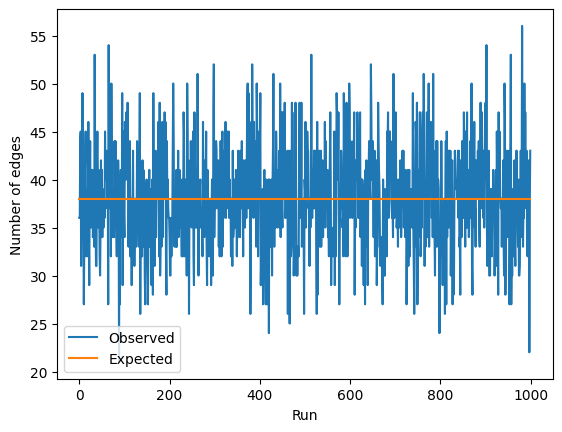

In [11]:
# Leave as-is

plt.xlabel("Run")
plt.ylabel("Number of edges")
plt.plot(range(trials), observed_edges, label="Observed")
plt.plot(range(trials), [expected_edges] * trials, label="Expected")
plt.legend()
plt.show()

Create a new generator, `generate_random_graph_avg_degree(N, kavg)` that given a target number of nodes, and a target average degree, determines the appropriate value of `p` to call `generate_random_graph(N, p)`, using the formulas seen in class.


In [12]:
def generate_random_graph_avg_degree(N, kavg):
    p = kavg / (N - 1)
    p = float(np.clip(p, 0.0, 1.0))
    return generate_random_graph(N, p)


Test your new generator. First, write a function ``graph_average_degree`` that returns the average degree of a graph.

Then, generate a series of graphs with a number of nodes *N=500* of your choice and expected average degree between 0.0 and 3.0 in increments of 0.1. The observed average degree of the resulting graph should be close to the given average degree.


In [13]:
def graph_average_degree(G):
    return np.mean([d for _, d in G.degree()])

N = 500
target_average_degrees = np.round(np.arange(0.0, 3.0 + 0.1, 0.1), 1).tolist()
observed_average_degrees = []

for kavg in target_average_degrees:
    G = generate_random_graph_avg_degree(N, kavg)
    observed_average_degrees.append(graph_average_degree(G))

The following compares visually the given average degree with the observed average degree.


/var/folders/cq/cf0203v96v77j5pntdgdq1y00000gr/T/ipykernel_8825/1970829798.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


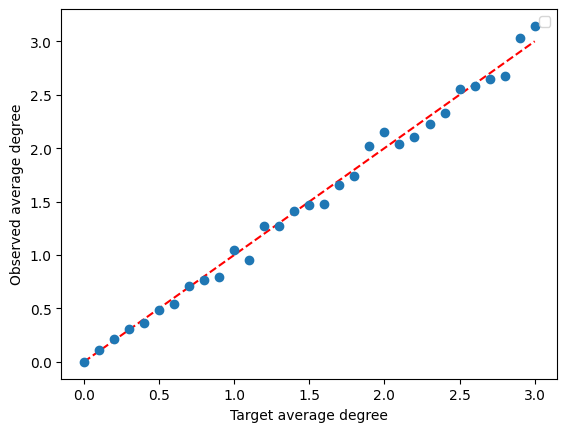

In [14]:
# Leave as-is

#!! Be careful make sure to run the previous cell just before running this one as we will be using some of the variables later and it can cause issues

plt.xlabel("Target average degree")
plt.ylabel("Observed average degree")
plt.scatter(target_average_degrees, observed_average_degrees)
plt.plot([0,max(target_average_degrees)], [0,max(target_average_degrees)], 'r--', zorder= 0)
plt.legend()
plt.show()

## 1.2. Measure connectivity


In [15]:
def is_connected(G):
    nodes = list(G.nodes)
    if len(nodes) <= 1:
        return True
    for u, v in itertools.combinations(nodes, 2):
        if not nx.has_path(G, u, v):
            return False
    return True

The following code, which you should leave as-is, returns the size of the largest connected component on a graph.


In [16]:
# Leave as-is

def size_largest_cc(G):

    # Obtain the list of connected components of the graph sorted from largest to smallest
    Gcc = sorted(nx.connected_components(G), key=len, reverse=True)

    # Selects the first connected component in that list
    G0 = G.subgraph(Gcc[0])

    # Returns its number of nodes
    return G0.number_of_nodes()

Create a series of ER graphs having *N=1000* nodes and target average degree  between *0.2* and *2.0* (e.g. *0.2, ..., 2.0*) with step *0.05* . Record: (1) their observed average degrees and (2) the size of their largest connected component as a fraction of the total number of nodes.

You can use the following skeleton:

```python
N = 1000
target_average_degrees = np.arange(0.2, 2.0, 0.05)

largest_cc_sizes = []
average_degrees = []

for target_average_degree in target_average_degrees:
    
    # Generate graph
    g = generate_random_graph_avg_degree(N, target_average_degree)
    assert g.number_of_nodes() == N, "Wrong number of nodes"
    
    # Obtain observed average degree
    average_degree = # YOUR CODE HERE
    average_degrees.append(average_degree)
    
    # Obtain size of largest connected component as a fraction of the total number of nodes
    largest_cc_size = # YOUR CODE HERE
    largest_cc_sizes.append(largest_cc_size)
```

Then, create a scatter plot of *average_degrees* (x axis) and *largest_cc_sizes* (y axis). Remember to label the axes of your plot appropriately.


In [18]:
N = 1000
target_average_degrees = np.arange(0.2, 2.0, 0.05)

largest_cc_sizes = []
average_degrees = []

for target_average_degree in target_average_degrees:
    g = generate_random_graph_avg_degree(N, target_average_degree)
    assert g.number_of_nodes() == N
    average_degree = graph_average_degree(g)
    average_degrees.append(average_degree)
    largest_cc_size = size_largest_cc(g) / N
    largest_cc_sizes.append(largest_cc_size)

The following code shows this visually.


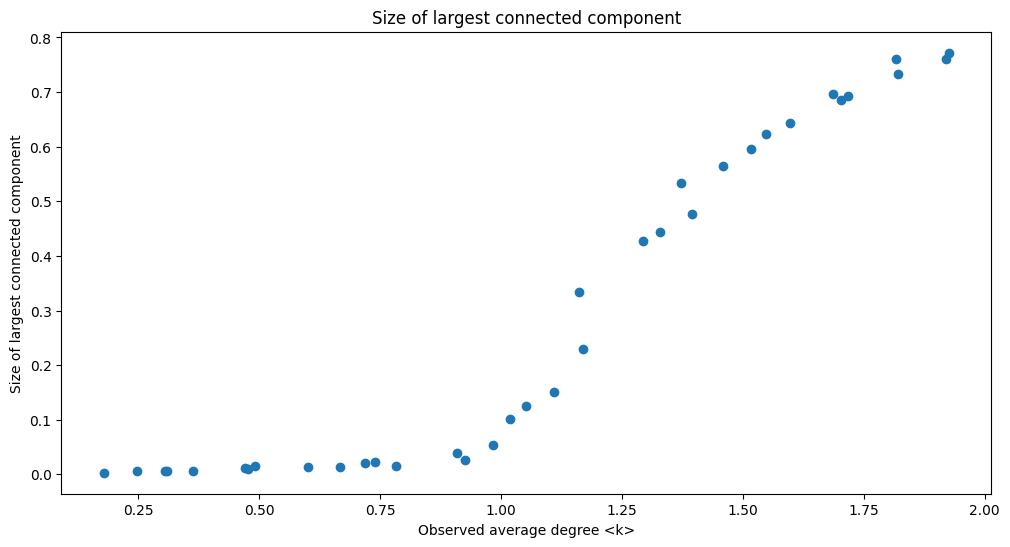

In [19]:
# LEAVE AS-IS

plt.figure(figsize=(12,6))
plt.scatter(average_degrees, largest_cc_sizes)
plt.title("Size of largest connected component")
plt.xlabel("Observed average degree <k>")
plt.ylabel("Size of largest connected component")
plt.show()

According to the theory, the largest connected component in an Erdős–Rényi graph starts to appear when the average degree is around 1. Below that, the graph is mostly small disconnected parts. In my experiment, the big component started forming at about 1.0 to 1.2, which is close to the theoretical value. The small difference happens because the graph has a finite number of nodes, so the transition isn’t perfectly sharp.

## 1.3. Degree distributions and Cumulative Degree Distributions

Create another function `print_er_statistics(g,p)` that given an ER graph and a probability *p* prints:

* its observed average degree *&lt;k&gt;*
* its expected average degree given *N* and *p*, using the formula seen in class

You can get a list of *(node, degree)* pairs by invoking `g.degree()`, or ask for the degree of node *u* using `g.degree(u)`.


In [20]:
def print_er_statistics(g, p):
    N = g.number_of_nodes()
    observed_k = np.mean([d for _, d in g.degree()])
    expected_k = p * (N - 1)
    print(f"N={N}, p={p:.3f} | observed <k>={observed_k:.3f} | expected <k>={expected_k:.3f}")

N = 500
p_values = [0.01, 0.03, 0.1]

g_list = []
for p in p_values:
    g = generate_random_graph(N, p)
    g_list.append(g)
    print_er_statistics(g, p)

N=500, p=0.010 | observed <k>=4.696 | expected <k>=4.990
N=500, p=0.030 | observed <k>=15.228 | expected <k>=14.970
N=500, p=0.100 | observed <k>=50.596 | expected <k>=49.900


You can use the following function (as-is, or modified) to plot the degree distribution in a graph.

In [22]:
# Leave as-is or modify if you want
def plot_degree_distributions(g_list, p_values):
    plt.figure(figsize=(12, 6))

    for g, p in zip(g_list, p_values):
        degree_dict = dict(g.degree())
        degree_sequence = list(degree_dict.values())

        prob, bin_edges = np.histogram(
            degree_sequence,
            bins=range(1, np.max(degree_sequence) + 2),
            density=True
        )

        plt.plot(bin_edges[:-1], prob, 'o-', label=f'p={p}')

    plt.title("Probability Density Function (Degree Distribution)")
    plt.xlabel("Degree")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


def plot_cumulative_degree_distributions(g_list, p_values):
    plt.figure(figsize=(12, 6))

    for g, p in zip(g_list, p_values):
        degree_dict = dict(g.degree())
        degree_sequence = list(degree_dict.values())

        degree_counts, bin_edges = np.histogram(
            degree_sequence,
            bins=range(1, np.max(degree_sequence) + 2),
            density=True
        )

        cumulative_distribution = np.cumsum(degree_counts[::-1])[::-1]

        plt.plot(bin_edges[:-1], cumulative_distribution, 'o-', label=f'p={p}')

    plt.title("Cumulative Degree Distribution (P(k' ≥ k))")
    plt.xlabel("Degree (k)")
    plt.ylabel("Cumulative Probability")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


N=2000, p=0.001 | observed <k>=1.014 | expected <k>=1.000
N=2000, p=0.001 | observed <k>=1.979 | expected <k>=1.999
N=2000, p=0.005 | observed <k>=9.919 | expected <k>=9.995
N=2000, p=0.010 | observed <k>=20.010 | expected <k>=19.990


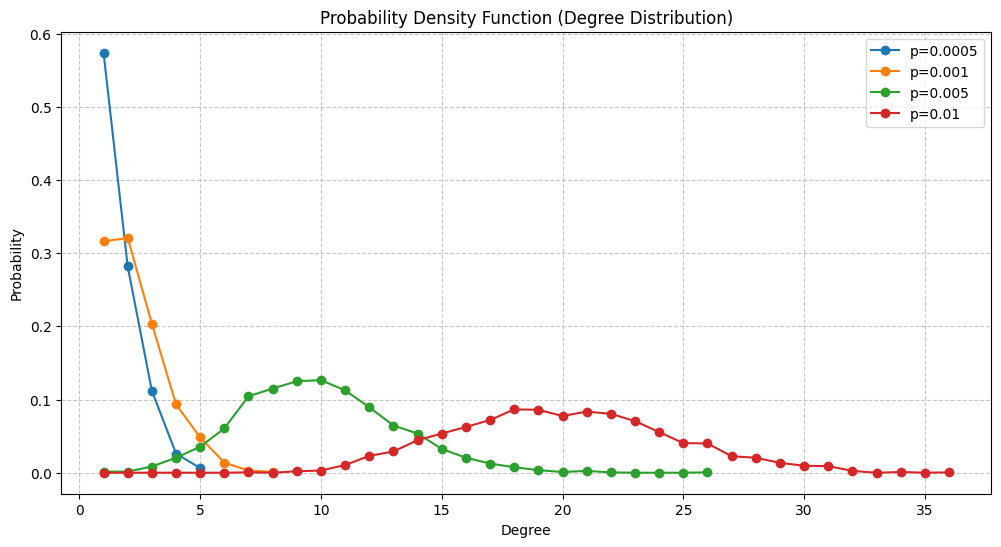

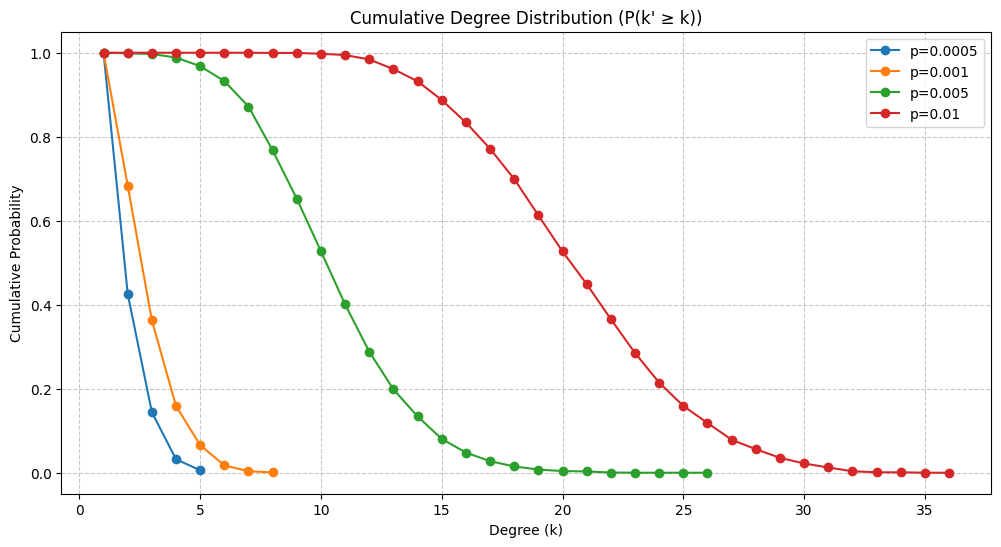

In [23]:
N = 2000
p_values = [0.0005, 0.001, 0.005, 0.01]

g_list = []

for p in p_values:
    g = generate_random_graph(N, p)
    g_list.append(g)
    print_er_statistics(g, p)

plot_degree_distributions(g_list, p_values)
plot_cumulative_degree_distributions(g_list, p_values)


# 2. Preferential attachment (BA) generator

In [ ]:
# LEAVE AS-IS

def select_with_probability(x, m, p):
    return np.random.choice(x, size=m, replace=False, p=p)

The next cell, which you should leave as-is, tests this function.

In [ ]:
# LEAVE AS-IS

trials = 1500
vector = ['a', 'b', 'c']
probabilities = [0.75, 0.13, 0.12]

all_selected = []
for i in range(trials):
    selected = select_with_probability(vector, 1, probabilities)[0]
    all_selected.append(selected)

for i, p in zip(vector, probabilities):
    print("Element {:s} was selected {:d} times, expected {:.0f}".format(i, all_selected.count(i), trials*p) )

Write code for creating a BA graph.

Start by creating an auxiliary function, `select_targets(g, m)` that selects *m* target nodes in a graph *g*, with probabilities proportional to the degrees of the nodes.

```python
def select_targets(g, m):

    # Check if feasible
    N = g.number_of_nodes()  
    if N < m:
        raise ValueError('Graph has less than m nodes')

    # Compute sum of degree
    sum_degree = 0

    # YOUR CODE HERE: COMPUTE SUM OF DEGREE OF NODES
    if sum_degree == 0:
        raise ValueError('Graph as no edges')

    # Compute probabilities
    probabilities = []
    for (node, degree) in g.degree():
        # YOUR CODE HERE: COMPUTE PROBABILITY OF SELECTING NODE u
        # THEN APPEND IT TO probabilities USING probabilities.append(...)

    # Sample
    selected = select_with_probability(g.nodes(), m, probabilities)

    return selected
´´´

In [1]:
def select_targets(g, m):
    N = g.number_of_nodes()
    if N < m:
        raise ValueError("Graph has less than m nodes")

    degrees = [d for _, d in g.degree()]
    sum_degree = sum(degrees)
    if sum_degree == 0:
        raise ValueError("Graph has no edges")

    probabilities = [d / sum_degree for d in degrees]

    selected = select_with_probability(list(g.nodes()), m, probabilities)
    return selected


Now, create a function `generate_preferential_attachment_graph(N, m0, m)` that:

1. Checks that *m <= m0* or raises a ValueError
1. Creates an empty graph
1. Adds nodes numbered from *0* to *m<sub>0</sub> - 1* to the graph
1. Creates a cycle by linking node *0* to node *1*, node *1* to node *2*, ..., node *m<sub>0</sub>-1* to node *0*
1. For every node *u* numbered from *m<sub>0</sub>* to *N - 1*
   1. Select *m* targets for this node using `select_targets`
   1. Add node *u* (remember to select targets **before** adding the node *u*)
   1. Link each node *u* to each of the *m* targets
1. Returns the graph

To test your code, you can do small experiments with, e.g., *N=100, m<sub>0</sub>=5, m=5* or *N=500, m<sub>0</sub>=2, m=1*, but do not include these small experimens with your deliverable.


In [2]:
def generate_preferential_attachment_graph(N, m0, m):
    if m > m0:
        raise ValueError("m must be ≤ m0")
    if N < m0:
        raise ValueError("N must be ≥ m0")

    G = nx.Graph()
    G.add_nodes_from(range(m0))

    for i in range(m0):
        G.add_edge(i, (i + 1) % m0)

    for u in range(m0, N):
        targets = select_targets(G, m)
        G.add_node(u)
        for v in targets:
            G.add_edge(u, v)

    return G


In [ ]:
# Leave as is
def estimate_alpha_mle(degrees, k_min=1):
    degrees = np.array(degrees)
    degrees = degrees[degrees >= k_min]
    n = len(degrees)
    alpha = 1 + n / np.sum(np.log(degrees / (k_min - 0.5)))
    return alpha

```python
def plot_degree_distribution_loglog(g, k_min=1):
    degree_dict = dict(g.degree())
    degree_sequence = np.array(list(degree_dict.values()))
    degree_sequence = degree_sequence[degree_sequence >= k_min]
    
    # Compute empirical histogram
    prob, bin_edges = np.histogram(
        degree_sequence,
        bins=range(k_min, np.max(degree_sequence)+2),
        density=True
    )
    
    x = bin_edges[:-1]
    y = prob
    
    # Remove zeros (log scale)
    mask = y > 0
    x = x[mask]
    y = y[mask]
    
    # Estimate alpha using MLE
    # ONE LINE TO FILL:
    alpha=
    
    # Compute fitted power-law line
    # Normalize to match the first bin of the empirical data
    y_fit=
    
    # Plot
    plt.figure(figsize=(12,6))
    plt.loglog(x, y, 'o', alpha=0.7, label='Empirical data')
    plt.loglog(x, y_fit, '--', color='red', label=f'MLE Power-law fit: α={alpha:.2f}')
    
    plt.xlabel("Degree (k)")
    plt.ylabel("P(k)")
    plt.title("Degree Distribution (Log-Log Scale)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
```

1. Complete plot_degree_distribution_log_log so that the resulting graph has the corresponding power-law fit.
2. Execute for two preferential attachment (BA) graphs with 5000 nodes, and values of *m0* and *m* (in the range 1-10)

Tip: To get a good fit you can use k_min=2*m .

The expected value of alpha in an ideal BA network is around 3.

# 3. ER and BA graph Comparison

In [3]:
#Leave as is
def plot_degree_distribution(g):
    degree_dict = dict(g.degree())
    degree_ordered = OrderedDict(sorted(degree_dict.items(), key=lambda x: x[1], reverse=True))
    degree_sequence = list(degree_ordered.values())
    prob, bin_edges = np.histogram(degree_sequence, bins=range(1,np.max(degree_sequence)+2), density=True)
    plt.figure(figsize=(12,6))
    plt.loglog(bin_edges[:-1], prob, 'o-')
    plt.title("Probability density function")
    plt.xlabel("degree")
    plt.ylabel("probability")
    plt.autoscale(enable=True, axis='both')
    plt.show()

To draw a graph, you can use:

```python
nx.draw_networkx(g)
```

You can have more control over the visualization of the graph, such as setting the figure size, removing the axis, using a particular layout algorithm, or changing the node size or color:

```python
plt.figure(figsize=(12,6))
plt.axis('off')
pos=nx.spring_layout(g)
nx.draw_networkx(g, pos, with_labels=True, node_size=500, node_color='lightgreen')
```

Tip: In the graph drawings of ER and BA graphs on this report you can use options `with_labels=False, node_size=10` (you can play with different values for `node_size`)

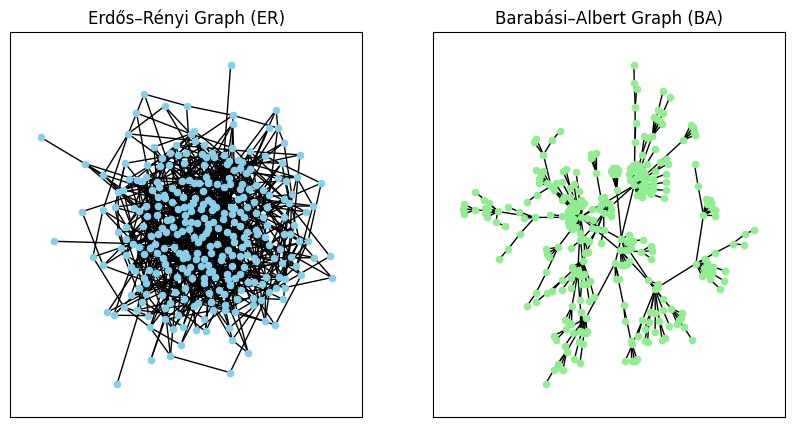

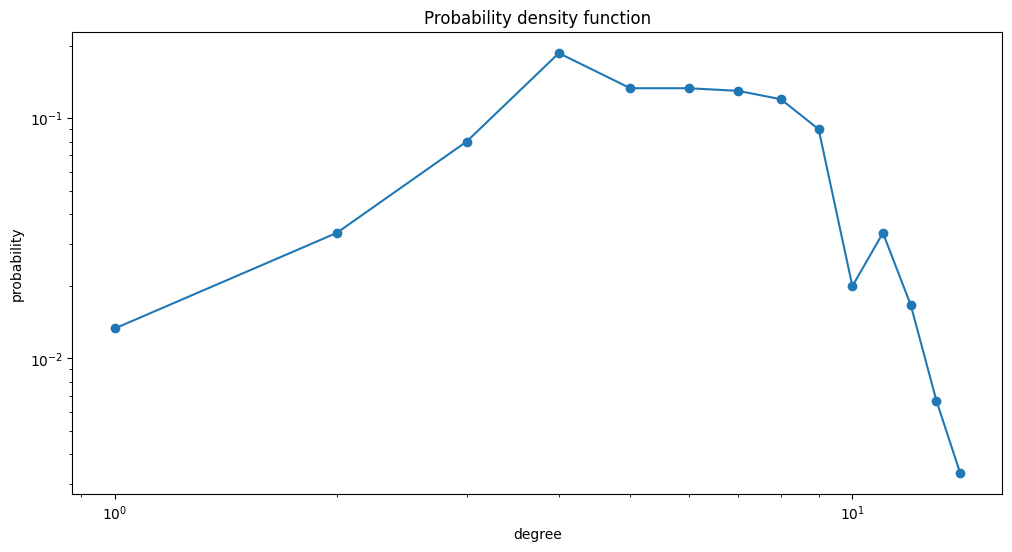

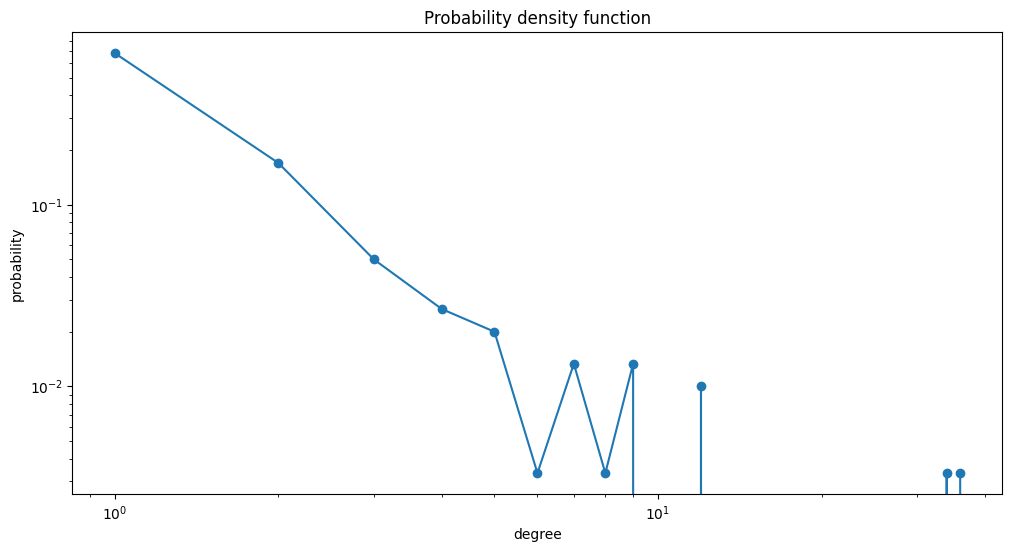

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# Parameters
N = 300
p = 0.02
m0 = 5
m = 1

# Generate graphs
G_er = nx.erdos_renyi_graph(N, p)
G_ba = nx.barabasi_albert_graph(N, m)

# Draw ER graph
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
pos = nx.spring_layout(G_er)
nx.draw_networkx(G_er, pos, node_size=20, with_labels=False, node_color='skyblue')
plt.title("Erdős–Rényi Graph (ER)")

# Draw BA graph
plt.subplot(1, 2, 2)
pos = nx.spring_layout(G_ba)
nx.draw_networkx(G_ba, pos, node_size=20, with_labels=False, node_color='lightgreen')
plt.title("Barabási–Albert Graph (BA)")
plt.show()

# Plot degree distributions
plot_degree_distribution(G_er)
plot_degree_distribution(G_ba)


1. The ER graph is random and uniform, while the BA graph forms hubs with highly connected nodes.
2. The ER graph shows a bell-shaped distribution, while the BA graph follows a power-law with a long tail.

<font size="+2" color="#003300">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>